### Data processing 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("./data/heart.csv")

In [50]:
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


# Bảng Giải Thích Bộ Dữ Liệu Dự Đoán Bệnh Tim (Heart Disease Dataset)

| Tên trường | Ý nghĩa ngắn gọn | Giá trị phổ biến |
| :--- | :--- | :--- |
| **age** | Tuổi bệnh nhân | Số năm |
| **sex** | Giới tính | `1` = Nam, `0` = Nữ |
| **cp** | Loại đau ngực | Mức độ từ `0` đến `3` |
| **trestbps** | Huyết áp lúc nghỉ ngơi | mm Hg |
| **chol** | Lượng cholesterol trong máu | mg/dl |
| **fbs** | Đường huyết lúc đói | `1` = > 120 mg/dl, `0` = <= 120 mg/dl |
| **restecg** | Kết quả điện tâm đồ (ECG) | `0` = Bình thường, `1`/`2` = Bất thường |
| **thalach** | Nhịp tim tối đa đạt được | Số nhịp/phút |
| **exang** | Đau ngực khi gắng sức | `1` = Có, `0` = Không |
| **oldpeak** | Chỉ số suy giảm đoạn ST | Số thực (đo mức độ thiếu máu cơ tim) |
| **slope** | Độ dốc đoạn ST khi gắng sức | `0` = Dốc lên, `1` = Đi ngang, `2` = Dốc xuống |
| **ca** | Số mạch máu chính được nhuộm màu | Từ `0` đến `3` (càng lớn càng nguy hiểm) |
| **thal** | Kết quả đo Thalassemia (máu) | `1` = Cố định, `2` = Bình thường, `3` = Đảo ngược |
| **target** | Kết luận bệnh tim (Nhãn) | `1` = Có bệnh, `0` = Không bệnh |

> **Lưu ý:** Cột `target` là biến mục tiêu cần dự đoán cho các bài toán Phân loại (Classification).

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
for item in features:
    data[item] = data[item].astype("category")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    int64   
 12  thal      303 non-null    category
 13  target    303 non-null    int64   
dtypes: category(7), float64(1), int64(6)
memory usage: 19.8 KB


In [9]:
data.describe()

,age,trestbps,chol,thalach,oldpeak,ca,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604,0.729373,0.544554
std,9.082101,17.538143,51.830751,22.905161,1.161075,1.022606,0.498835
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000,0.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,1.000000
75%,61.000000,140.000000,274.500000,166.000000,1.600000,1.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,1.000000


In [11]:
from sklearn.model_selection import train_test_split
x = data.drop("target", axis=1)
y = data["target"]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# 3. Chỉ scale trên các cột số liên tục (ví dụ: age, trestbps, chol, thalach, oldpeak)
# Không scale các cột danh mục 0 và 1 đã One-Hot Encoding, nếu scale sẽ biến 0-1 thành các số 0,01982, -1,9162 làm mất giá trị vốn có
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [14]:
x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,-1.356798,1,1,-0.616856,0.914034,0,1,0.532781,0,-0.920864,2,0,2
202,0.385086,1,0,1.169491,0.439527,0,0,-1.753582,1,-0.193787,2,0,3
196,-0.921327,1,2,1.169491,-0.300704,0,1,-0.139679,0,2.350982,1,0,2
75,0.058483,0,1,0.276318,0.059921,0,0,0.487950,0,0.351521,1,0,2
176,0.602822,1,0,-0.795490,-0.319684,1,1,0.443119,1,0.351521,2,2,3


In [15]:
x_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,0.276218,1,0,1.169491,0.553408,0,0,-1.708752,1,-0.375556,1,1,1
228,0.493954,1,3,2.360389,0.781172,0,0,0.398289,0,-0.739095,1,0,3
111,0.276218,1,2,1.169491,-2.293633,1,1,1.025918,0,-0.739095,2,1,3
246,0.167350,0,0,0.216773,3.077785,0,0,-0.005187,1,0.805944,1,2,3
60,1.800367,0,2,-1.212304,0.344625,1,0,-0.901800,0,-0.920864,2,1,2


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [17]:
models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForestClassifier": RandomForestClassifier()
}

for name, model in models.items():
    model = model.fit(x_train, y_train)
    predict = model.predict(x_test)
    print(f"=== KẾT QUẢ CỦA {name.upper()} ===")
    print(classification_report(y_test, predict))
    print("-"*40)

=== KẾT QUẢ CỦA LOGISTICREGRESSION ===
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

----------------------------------------
=== KẾT QUẢ CỦA RANDOMFORESTCLASSIFIER ===
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

----------------------------------------


In [37]:
#Có bệnh
import numpy as np

# 1. Tạo DataFrame chứa dữ liệu bệnh nhân mẫu (nhớ điền đúng thứ tự cột lúc train của bạn)
columns_order = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
new_patient_raw = pd.DataFrame([[63, 1, 3, 145,	233, 1,	0, 150,	0, 2.3,	0, 0, 1]], columns=columns_order)

# 2. CHÈN THÊM BƯỚC NÀY: Chỉ scale các cột số liên tục bằng bộ scaler cũ
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
new_patient_scaled = new_patient_raw.copy()
new_patient_scaled[num_cols] = scaler.transform(new_patient_raw[num_cols])

# 3. Đưa dữ liệu ĐÃ SCALE vào mô hình để dự đoán
new_predict = model.predict_proba(new_patient_scaled)

print(new_predict)
percentClass01 = new_predict[0][1] * 100
percentClass00 = new_predict[0][0] * 100

print(f"Nguy cơ mắc bệnh của bạn là {percentClass01:.0f}%")
print(f"Tỉ lệ không mắc bệnh là {percentClass00:.0f}%")

[[0.2 0.8]]
Nguy cơ mắc bệnh của bạn là 80%
Tỉ lệ không mắc bệnh là 20%


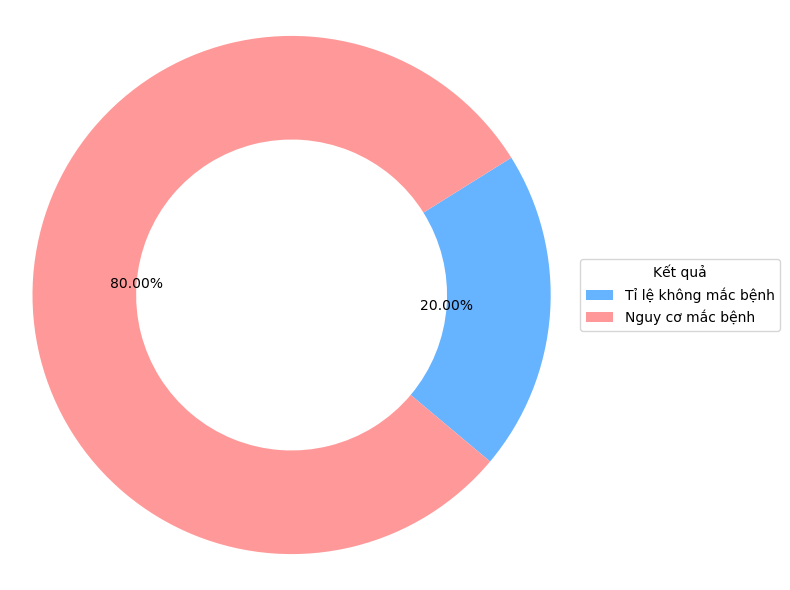

In [46]:
labels = ["Tỉ lệ không mắc bệnh", "Nguy cơ mắc bệnh"]

sizes = [percentClass00, percentClass01]

colors = ['#66b3ff', '#ff9999']

# Tạo text phần trăm chính xác
display_percent = [
    f"{percentClass00:.2f}%",
    f"{percentClass01:.2f}%"
]

fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw=dict(aspect="equal")
)

wedges, texts, autotexts = ax.pie(
    sizes,
    wedgeprops=dict(width=0.4),
    startangle=-40,
    colors=colors,
    autopct=lambda pct: display_percent.pop(0)
)

ax.legend(
    wedges,
    labels,
    title="Kết quả",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.axis('equal')

plt.tight_layout()
plt.show()

In [30]:
notdisease = data[data["target"] == 0]
notdisease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
165,67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
166,67,1,0,120,229,0,0,129,1,2.6,1,2,3,0
167,62,0,0,140,268,0,0,160,0,3.6,0,2,2,0
168,63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
169,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [48]:
#Tỉ lệ bệnh thấp
# 1. Tạo DataFrame chứa dữ liệu bệnh nhân mẫu (nhớ điền đúng thứ tự cột lúc train của bạn)
columns_order = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
new_patient_raw = pd.DataFrame([[45, 1,	3, 110,	264, 0, 1, 132,	0,	1.2, 1,	0, 3]], columns=columns_order)

# 2. CHÈN THÊM BƯỚC NÀY: Chỉ scale các cột số liên tục bằng bộ scaler cũ
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
new_patient_scaled = new_patient_raw.copy()
new_patient_scaled[num_cols] = scaler.transform(new_patient_raw[num_cols])

# 3. Đưa dữ liệu ĐÃ SCALE vào mô hình để dự đoán
new_predict = model.predict_proba(new_patient_scaled)

print(new_predict)
percentClass01 = new_predict[0][1] * 100
percentClass00 = new_predict[0][0] * 100

print(f"Nguy cơ mắc bệnh của bạn là {percentClass01:.0f}%")
print(f"Tỉ lệ không mắc bệnh là {percentClass00:.0f}%")

[[0.84 0.16]]
Nguy cơ mắc bệnh của bạn là 16%
Tỉ lệ không mắc bệnh là 84%


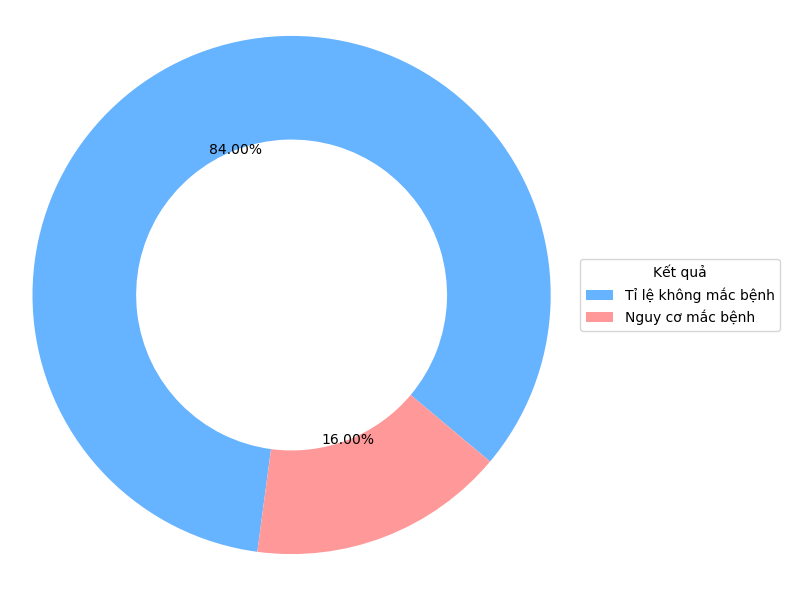

In [49]:
labels = ["Tỉ lệ không mắc bệnh", "Nguy cơ mắc bệnh"]

sizes = [percentClass00, percentClass01]

colors = ['#66b3ff', '#ff9999']

# Tạo text phần trăm chính xác
display_percent = [
    f"{percentClass00:.2f}%",
    f"{percentClass01:.2f}%"
]

fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw=dict(aspect="equal")
)

wedges, texts, autotexts = ax.pie(
    sizes,
    wedgeprops=dict(width=0.4),
    startangle=-40,
    colors=colors,
    autopct=lambda pct: display_percent.pop(0)
)

ax.legend(
    wedges,
    labels,
    title="Kết quả",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.axis('equal')

plt.tight_layout()
plt.show()

In [20]:
# import joblib
# joblib.dump(model, 'best_heart_disease_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']